In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

print("Basic libraries imported!")

Basic libraries imported!


In [7]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("NLP and ML libraries imported!")

NLP and ML libraries imported!


In [4]:
import glob

glob.glob("/content/*.csv")

['/content/train.csv']

In [9]:
with open("/content/train.csv", "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

for i in range(139160, 139176):
    print(f"LINE {i}:")
    print(lines[i-1])
    print("-" * 100)

LINE 139160:
1,Cookie Cutter Corporate Rock,"I heard the raves about The Vines (on the radio, Rolling Stones article) and decided to purchase this album. I read how the lead singer wants to compare himself to Kurt Cobain. Well, this album is nothing like Grunge Rock. And the lead singer is no Cobain. The Vines do not sound like a garage band. They sound and appear to be an exact replica of what producers and record execs want--clean, boring, pseudo-angst driven. But then again, the album's graphic designs should hint at that. What do you think the target age group here is?? There's none of Grunge's sensitive introspection and emotion here. This album as well as the whole new 'Brit-Pop sound' is a complete laugh, and so are the comparisons to a former Northwestern Grunge music.If you want to listen to garage-style music, try something else. If you want Grunge, try the Nixons, Replacements, Vaselines, Melvins, Alice, Tad, Mudhoney, Sebadoh, Soundgarden, Nirvana, etc., not this."

-------

In [11]:
import pandas as pd

df = pd.read_csv(
    "/content/train.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Shape:", df.shape)
df.head()

Shape: (480066, 3)


,class_index,review_title,review_text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [12]:
print(df.columns.tolist())

['class_index', 'review_title', 'review_text']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480066 entries, 0 to 480065
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   class_index   480066 non-null  int64 
 1   review_title  480034 non-null  object
 2   review_text   480066 non-null  object
dtypes: int64(1), object(2)
memory usage: 11.0+ MB


In [14]:
df.columns.tolist()

['class_index', 'review_title', 'review_text']

In [15]:
df["class_index"].value_counts().sort_index()

,count
class_index,
1,237522
2,242544


In [16]:
df["class_index"].value_counts(
    normalize=True
).sort_index() * 100

,proportion
class_index,
1,49.476947
2,50.523053


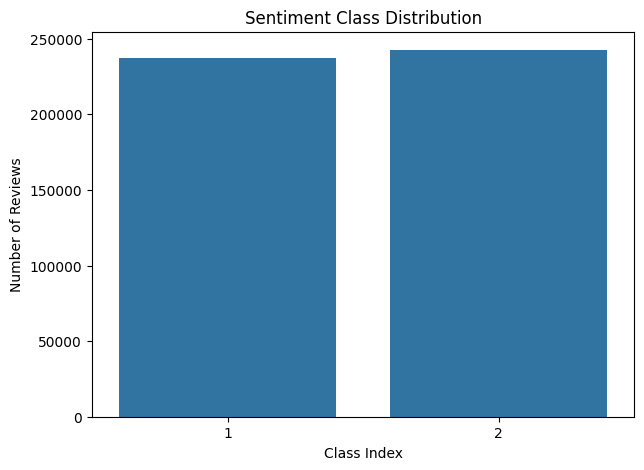

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class_index"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Class Index")
plt.ylabel("Number of Reviews")

plt.show()

In [18]:
df["review"] = (
    df["review_title"].fillna("") +
    " " +
    df["review_text"].fillna("")
)

In [19]:
df[
    ["review_title", "review_text", "review"]
].head()

,review_title,review_text,review
0,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,Stuning even for the non-gamer This sound trac...
1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,The best soundtrack ever to anything. I'm read...
2,Amazing!,This soundtrack is my favorite music of all ti...,Amazing! This soundtrack is my favorite music ...
3,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,Excellent Soundtrack I truly like this soundtr...
4,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...","Remember, Pull Your Jaw Off The Floor After He..."


In [20]:
df.groupby("class_index")["review"].count()

,review
class_index,
1,237522
2,242544


In [21]:
sorted(df["class_index"].unique())

[np.int64(1), np.int64(2)]

In [22]:
df.isnull().sum()

,0
class_index,0
review_title,32
review_text,0
review,0


In [23]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [24]:
df["review_length"] = (
    df["review"]
    .str.len()
)

In [25]:
df["review_length"].describe()

,review_length
count,480066.000000
mean,437.881171
std,239.495399
min,90.000000
25%,235.000000
50%,391.000000
75%,606.000000
max,1014.000000


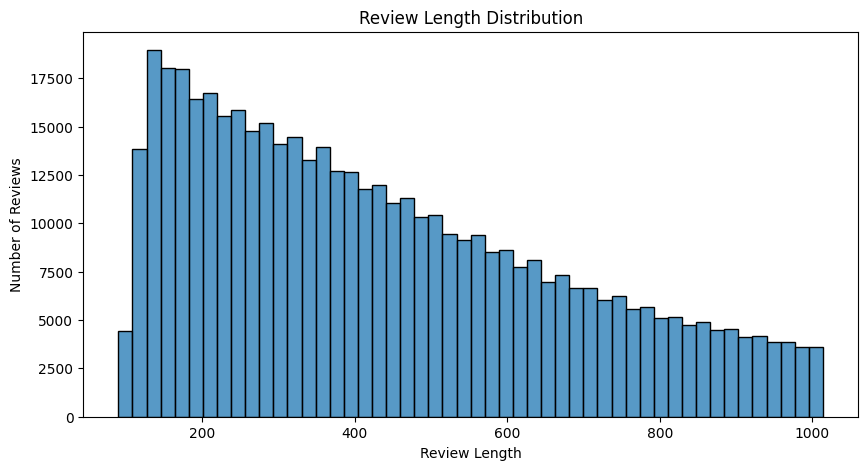

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="review_length",
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")

plt.show()

In [27]:
df["class_index"].value_counts()

,count
class_index,
2,242544
1,237522


In [28]:
sorted(df["class_index"].unique())

[np.int64(1), np.int64(2)]

In [29]:
df.isnull().sum()

,0
class_index,0
review_title,32
review_text,0
review,0
review_length,0


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df["sentiment"] = df["class_index"].map({
    1: 0,   # Negative
    2: 1    # Positive
})

In [32]:
df[["class_index", "sentiment"]].head()

,class_index,sentiment
0,2,1
1,2,1
2,2,1
3,2,1
4,2,1


In [33]:
df["sentiment"].value_counts()

,count
sentiment,
1,242544
0,237522


In [34]:
df["review_title"] = df["review_title"].fillna("")

In [35]:
df["review"] = (
    df["review_title"] + " " +
    df["review_text"]
).str.strip()

In [36]:
df[["review_title", "review_text", "review"]].head()

,review_title,review_text,review
0,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,Stuning even for the non-gamer This sound trac...
1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,The best soundtrack ever to anything. I'm read...
2,Amazing!,This soundtrack is my favorite music of all ti...,Amazing! This soundtrack is my favorite music ...
3,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,Excellent Soundtrack I truly like this soundtr...
4,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...","Remember, Pull Your Jaw Off The Floor After He..."


In [37]:
from sklearn.model_selection import train_test_split

df_subset, _ = train_test_split(
    df,
    train_size=100000,
    random_state=42,
    stratify=df["sentiment"]
)

df_subset = df_subset.reset_index(drop=True)

print("Subset shape:", df_subset.shape)

Subset shape: (100000, 6)


In [38]:
df_subset["sentiment"].value_counts(normalize=True) * 100

,proportion
sentiment,
1,50.523
0,49.477


In [39]:
import re
import string

def clean_text(text):
    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"\d+",
        " ",
        text
    )

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [40]:
df_subset["clean_review"] = (
    df_subset["review"]
    .apply(clean_text)
)

In [41]:
df_subset[
    ["review", "clean_review"]
].head()

,review,clean_review
0,Buy the tape and buy his stock Berkshire Hatha...,buy the tape and buy his stock berkshire hatha...
1,"This is an excellent, genuine Beanie BUDDY! Th...",this is an excellent genuine beanie buddy this...
2,very disappointed This was a Christmas gift fo...,very disappointed this was a christmas gift fo...
3,Grammaire des civilisations This book is extra...,grammaire des civilisations this book is extra...
4,"""The Abyss"" I thought the movie was way too lo...",the abyss i thought the movie was way too long...


In [42]:
df_subset["review_length"] = (
    df_subset["clean_review"].str.len()
)

In [43]:
df_subset["review_length"].describe()

,review_length
count,100000.000000
mean,420.943580
std,230.659014
min,58.000000
25%,226.000000
50%,375.000000
75%,582.000000
max,999.000000


In [44]:
df_subset["review_length"].describe()

,review_length
count,100000.000000
mean,420.943580
std,230.659014
min,58.000000
25%,226.000000
50%,375.000000
75%,582.000000
max,999.000000


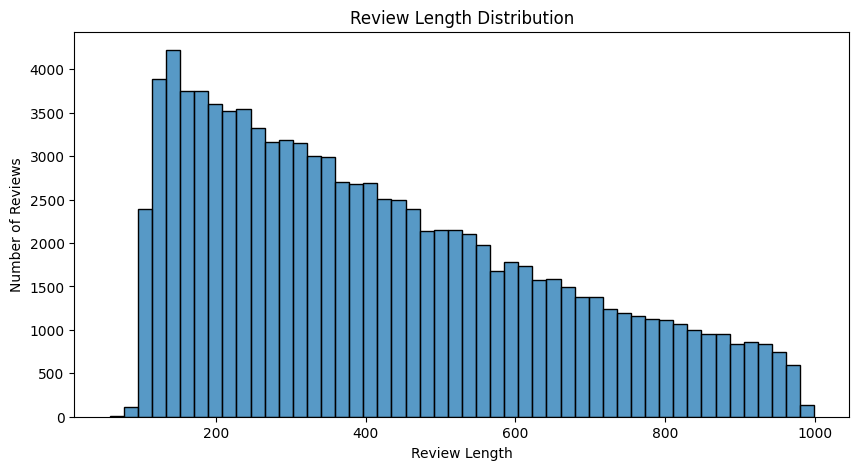

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_subset,
    x="review_length",
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")

plt.show()

In [46]:
X = df_subset["clean_review"]
y = df_subset["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (80000,)
Testing : (20000,)


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            tfidf
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [49]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('model', LogisticRegression(max_iter=1000))])

In [50]:
y_pred_lr = logistic_pipeline.predict(
    X_test
)

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Accuracy : 0.9112
Precision: 0.9142
Recall   : 0.9095
F1-Score : 0.9118


In [52]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      9895
           1       0.91      0.91      0.91     10105

    accuracy                           0.91     20000
   macro avg       0.91      0.91      0.91     20000
weighted avg       0.91      0.91      0.91     20000



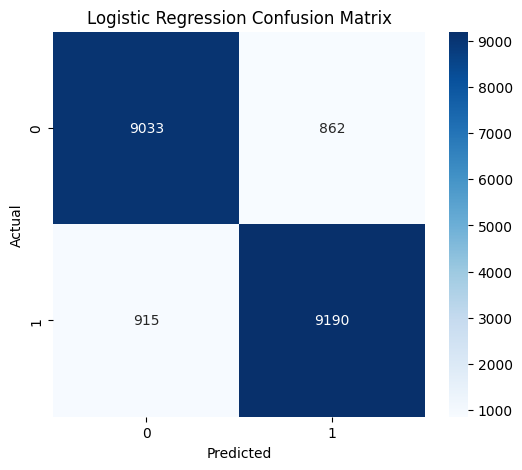

In [53]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
feature_names = (
    logistic_pipeline
    .named_steps["tfidf"]
    .get_feature_names_out()
)

In [55]:
coefficients = (
    logistic_pipeline
    .named_steps["model"]
    .coef_[0]
)

In [56]:
word_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [57]:
top_positive = (
    word_importance
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(20)
)

top_positive

,Feature,Coefficient
9817,great,13.410472
7757,excellent,9.768711
3228,best,7.056092
18294,perfect,6.887790
29189,wonderful,6.858930
2565,awesome,6.790728
869,amazing,6.701078
9601,good,6.617477
14415,love,5.437670
9131,fun,5.253536


In [58]:
top_negative = (
    word_importance
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .head(20)
)

top_negative

,Feature,Coefficient
16345,not,-12.386693
3735,boring,-10.108906
29383,worst,-9.079019
18703,poor,-8.938358
6523,disappointing,-8.935336
6503,disappointed,-8.362648
11174,horrible,-7.621624
23161,terrible,-7.572548
6529,disappointment,-7.263463
28102,waste,-7.056941


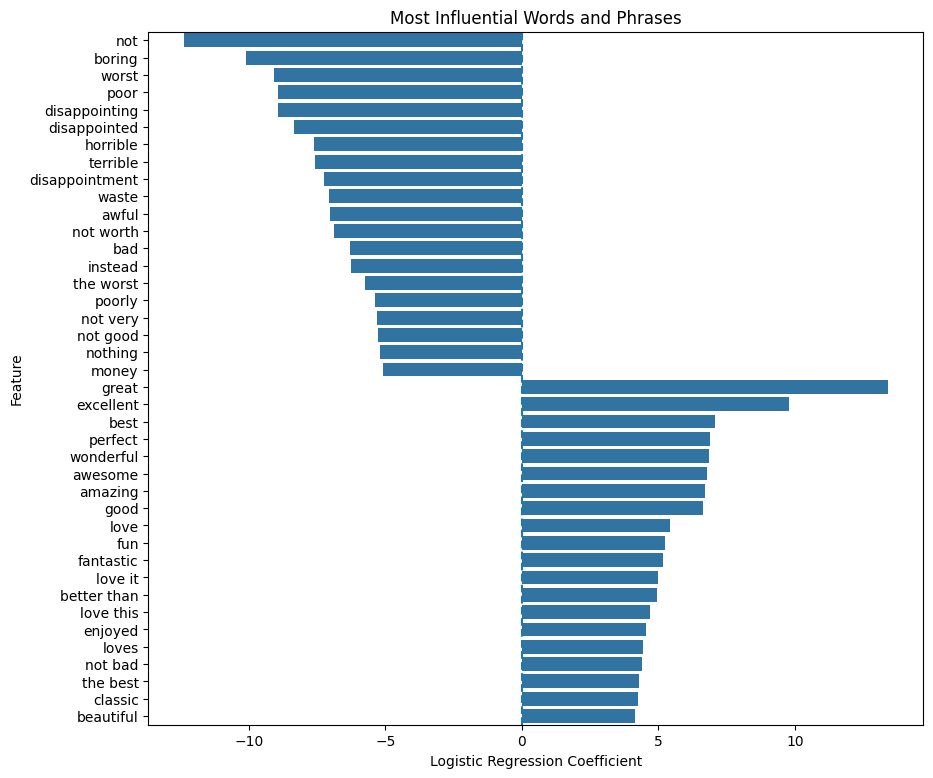

In [59]:
top_words = pd.concat([
    top_negative,
    top_positive
])

plt.figure(figsize=(10, 9))

sns.barplot(
    data=top_words,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Most Influential Words and Phrases"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [60]:
from sklearn.naive_bayes import MultinomialNB

In [61]:
nb_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=30000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "model",
            MultinomialNB()
        )
    ]
)

In [62]:
nb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('model', MultinomialNB())])

In [63]:
y_pred_nb = nb_pipeline.predict(
    X_test
)

In [64]:
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_precision = precision_score(
    y_test,
    y_pred_nb
)

nb_recall = recall_score(
    y_test,
    y_pred_nb
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb
)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")

Accuracy : 0.8904
Precision: 0.8955
Recall   : 0.8866
F1-Score : 0.8910


In [65]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      9895
           1       0.90      0.89      0.89     10105

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



In [66]:
from sklearn.svm import LinearSVC

In [67]:
svm_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=30000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "model",
            LinearSVC(
                C=1.0
            )
        )
    ]
)

In [68]:
svm_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('model', LinearSVC())])

In [69]:
y_pred_svm = svm_pipeline.predict(
    X_test
)

In [70]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm
)

svm_recall = recall_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

Accuracy : 0.9102
Precision: 0.9133
Recall   : 0.9085
F1-Score : 0.9108


In [71]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      9895
           1       0.91      0.91      0.91     10105

    accuracy                           0.91     20000
   macro avg       0.91      0.91      0.91     20000
weighted avg       0.91      0.91      0.91     20000



In [72]:
nlp_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall,
        svm_recall
    ],
    "F1": [
        lr_f1,
        nb_f1,
        svm_f1
    ]
})

nlp_comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.91115,0.914246,0.909451,0.911842
1,Naive Bayes,0.89045,0.895542,0.886591,0.891044
2,Linear SVM,0.91015,0.913251,0.908461,0.910850


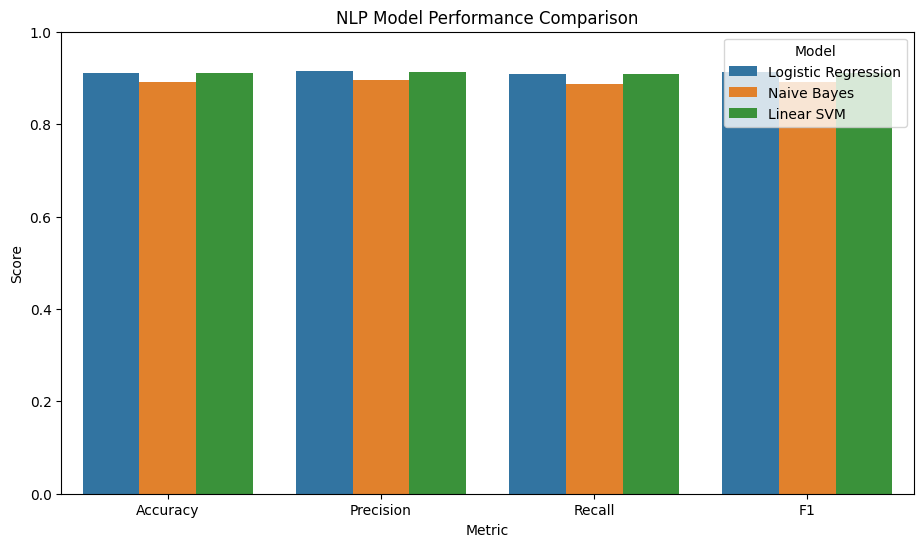

In [73]:
comparison_long = nlp_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("NLP Model Performance Comparison")
plt.ylabel("Score")

plt.show()

In [74]:
from sklearn.model_selection import GridSearchCV

logistic_tuning = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=30000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [75]:
param_grid = {
    "tfidf__max_features": [
        20000,
        30000,
        50000
    ],
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],
    "model__C": [
        0.1,
        1,
        3
    ]
}

In [76]:
grid_search = GridSearchCV(
    estimator=logistic_tuning,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [77]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95,
                                                        max_features=30000,
                                                        min_df=2,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 3],
                         'tfidf__max_features': [20000, 30000, 50000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1', verbose=1)

In [78]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 3, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}

Best CV F1:
0.9116263952994998


In [79]:
best_nlp_model = grid_search.best_estimator_

In [80]:
y_pred_tuned = best_nlp_model.predict(
    X_test
)

In [81]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")

Accuracy : 0.9159
Precision: 0.9193
Recall   : 0.9138
F1-Score : 0.9165


In [82]:
print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      9895
           1       0.92      0.91      0.92     10105

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



In [83]:
final_nlp_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        nb_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision,
        nb_precision,
        tuned_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall,
        nb_recall,
        tuned_recall
    ],
    "F1": [
        lr_f1,
        svm_f1,
        nb_f1,
        tuned_f1
    ]
})

final_nlp_comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.91115,0.914246,0.909451,0.911842
1,Linear SVM,0.91015,0.913251,0.908461,0.910850
2,Naive Bayes,0.89045,0.895542,0.886591,0.891044
3,Tuned Logistic Regression,0.91590,0.919263,0.913805,0.916526


In [84]:
error_analysis = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred_tuned
})

errors = error_analysis[
    error_analysis["Actual"] !=
    error_analysis["Predicted"]
]

errors.head(20)

,Review,Actual,Predicted
28,dear walt disney do you think were fools first...,0,1
34,movie good picturesound quality okone of the f...,1,0
39,moron lmao this loser ate supersized meals tim...,0,1
41,ossian i first read large chunks of this in fr...,1,0
47,this was not that great this book put me to sl...,0,1
60,word or less review gory goofy bmovie of a mot...,1,0
73,my lid never falls off ive been using this bri...,1,0
83,esperaba mas de este dvd compré muy emocionado...,0,1
102,flawed laptop now working great my v ax is fro...,1,0
118,man im so sorry yeah i never knew this book wa...,1,0


In [85]:
error_analysis = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred_tuned
})

errors = error_analysis[
    error_analysis["Actual"] !=
    error_analysis["Predicted"]
].copy()

print("Total errors:", len(errors))

Total errors: 1682


In [86]:
errors.head(20)

,Review,Actual,Predicted
28,dear walt disney do you think were fools first...,0,1
34,movie good picturesound quality okone of the f...,1,0
39,moron lmao this loser ate supersized meals tim...,0,1
41,ossian i first read large chunks of this in fr...,1,0
47,this was not that great this book put me to sl...,0,1
60,word or less review gory goofy bmovie of a mot...,1,0
73,my lid never falls off ive been using this bri...,1,0
83,esperaba mas de este dvd compré muy emocionado...,0,1
102,flawed laptop now working great my v ax is fro...,1,0
118,man im so sorry yeah i never knew this book wa...,1,0


In [87]:
false_positive = errors[
    (errors["Actual"] == 0) &
    (errors["Predicted"] == 1)
]

false_positive.head(10)

,Review,Actual,Predicted
28,dear walt disney do you think were fools first...,0,1
39,moron lmao this loser ate supersized meals tim...,0,1
47,this was not that great this book put me to sl...,0,1
83,esperaba mas de este dvd compré muy emocionado...,0,1
167,omg this dvd is for those who are in shape if ...,0,1
213,christmas carol i purchased this version of th...,0,1
249,less funk more folk jacob berendes ordem e pro...,0,1
275,death by family so far this book is killing me...,0,1
316,karl bartos do better i hear the complete cd a...,0,1
320,one long interior monologue delivered by milqu...,0,1


In [88]:
false_negative = errors[
    (errors["Actual"] == 1) &
    (errors["Predicted"] == 0)
]

false_negative.head(10)

,Review,Actual,Predicted
34,movie good picturesound quality okone of the f...,1,0
41,ossian i first read large chunks of this in fr...,1,0
60,word or less review gory goofy bmovie of a mot...,1,0
73,my lid never falls off ive been using this bri...,1,0
102,flawed laptop now working great my v ax is fro...,1,0
118,man im so sorry yeah i never knew this book wa...,1,0
151,genius work yet could of been better spielberg...,1,0
255,i loved of this book well i agree with another...,1,0
277,stars the return of the fighting brothers oasi...,1,0
295,cant remember when ive laughed so hard i cant ...,1,0


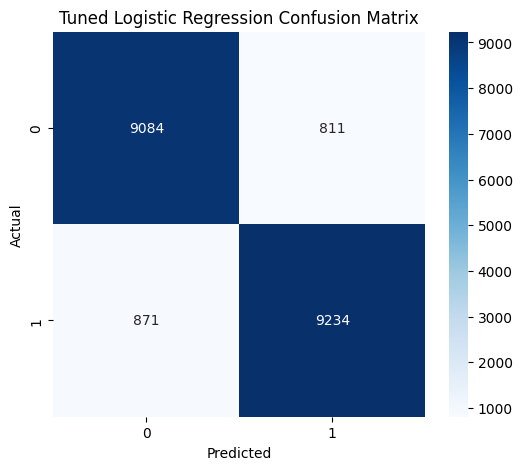

In [89]:
cm_final = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [90]:
final_tfidf = (
    best_nlp_model
    .named_steps["tfidf"]
)

final_model = (
    best_nlp_model
    .named_steps["model"]
)

feature_names_final = (
    final_tfidf
    .get_feature_names_out()
)

coefficients_final = (
    final_model.coef_[0]
)

final_word_importance = pd.DataFrame({
    "Feature": feature_names_final,
    "Coefficient": coefficients_final
})

In [91]:
final_positive = (
    final_word_importance
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(20)
)

final_positive

,Feature,Coefficient
16417,great,17.166355
12981,excellent,12.561902
5413,best,9.610179
16032,good,9.039424
48690,wonderful,8.998076
30654,perfect,8.801319
1433,amazing,8.771292
4287,awesome,8.715867
23977,love it,7.814032
27330,not bad,7.466278


In [92]:
final_negative = (
    final_word_importance
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .head(20)
)

final_negative

,Feature,Coefficient
27303,not,-15.729783
6250,boring,-13.121437
10884,disappointing,-12.631494
49006,worst,-12.015545
31330,poor,-11.438468
10858,disappointed,-11.188087
27637,not worth,-10.842645
18704,horrible,-10.410550
10901,disappointment,-10.325252
4303,awful,-10.275007


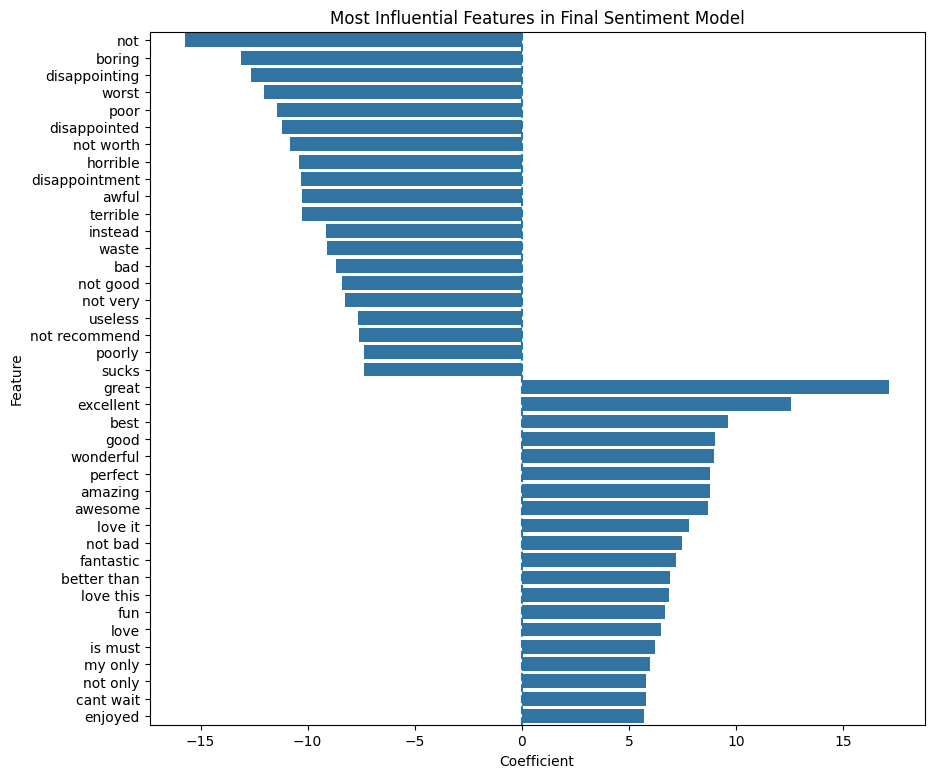

In [93]:
final_words = pd.concat([
    final_negative,
    final_positive
])

plt.figure(figsize=(10, 9))

sns.barplot(
    data=final_words,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Most Influential Features in Final Sentiment Model"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## Key Findings

### 1. The dataset is well balanced

The analysis used a stratified subset of 100,000 reviews.

The sentiment distribution was:

- Positive: 50.52%
- Negative: 49.48%

This balanced distribution reduces the risk of the model being biased toward one sentiment class.

### 2. Logistic Regression provided a strong baseline

The initial TF-IDF Logistic Regression achieved:

- Accuracy: 91.12%
- Precision: 91.24%
- Recall: 90.95%
- F1-Score: 91.18%

This demonstrates that traditional TF-IDF-based text representation combined with Logistic Regression can perform strongly on large-scale binary sentiment classification.

### 3. Model comparison showed similar performance between Logistic Regression and Linear SVM

Linear SVM achieved performance close to Logistic Regression, while Naive Bayes performed lower.

The initial comparison was:

| Model | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 91.12% | 91.24% | 90.95% | 91.18% |
| Linear SVM | 91.02% | 91.33% | 90.85% | 91.09% |
| Naive Bayes | 89.05% | 89.55% | 88.66% | 89.10% |

### 4. Hyperparameter tuning improved the final model

After tuning TF-IDF and Logistic Regression parameters, the final model achieved:

- Accuracy: 91.59%
- Precision: 91.93%
- Recall: 91.38%
- F1-Score: 91.65%

The improvement was consistent across all major evaluation metrics.

### 5. Positive and negative words were strongly interpretable

The final Logistic Regression coefficients showed that words and phrases such as:

- great
- excellent
- best
- good
- wonderful
- perfect
- amazing
- awesome
- love it

were strongly associated with positive sentiment.

Meanwhile, terms such as:

- boring
- disappointing
- worst
- poor
- disappointed
- horrible
- awful
- terrible
- not worth
- not good

were strongly associated with negative sentiment.

### 6. Model errors were concentrated in context-heavy reviews

The final model produced 1,682 incorrect predictions out of 20,000 test reviews.

Several misclassified reviews contained:

- positive and negative words in the same sentence
- negations
- mixed opinions
- contextual expressions
- informal language

These cases show the limitations of traditional TF-IDF representations, which mainly capture word and phrase frequency rather than deeper semantic context.

## Business Insight

A sentiment classification system can be used to automatically process large volumes of customer reviews and summarize customer opinions.

Potential applications include:

- Monitoring customer satisfaction
- Identifying negative product feedback
- Prioritizing reviews for customer support
- Tracking sentiment changes over time
- Supporting product quality analysis
- Summarizing customer feedback at scale

Positive sentiment can help identify aspects of products or services that customers appreciate, while negative sentiment can highlight areas requiring improvement.

The model can therefore serve as an initial automated screening layer before detailed human review.

## Conclusion

This project developed a binary sentiment analysis system for customer reviews using Natural Language Processing and machine learning.

The workflow included data preparation, text cleaning, TF-IDF feature extraction, model comparison, hyperparameter tuning, error analysis, and model interpretation.

Three classification approaches were evaluated: Logistic Regression, Naive Bayes, and Linear SVM. Logistic Regression achieved the strongest overall baseline performance, while the tuned Logistic Regression model became the final model.

The final model achieved:

- Accuracy: **91.59%**
- Precision: **91.93%**
- Recall: **91.38%**
- F1-Score: **91.65%**

The interpretation of model coefficients also showed that the classifier learned meaningful positive and negative sentiment patterns from words and phrases in the reviews.

However, the error analysis demonstrated that the model still struggles with contextual language, negation, and mixed sentiment. These limitations suggest that future work could explore more advanced NLP approaches, such as word embeddings, transformer-based models, or contextual language models.

Overall, this project demonstrates how traditional NLP techniques and machine learning can be used to transform unstructured customer reviews into structured sentiment information that can support automated feedback analysis.